__MLP Model__

Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality.

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

These models both use 2 classes of water quality as targets: good vs not good. The poor/moderate classes are combined (0), whilst the good class remains seperate (2).

In [11]:
#Imports

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

#scikit-learn
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

#For the model
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import shap

In [12]:
#Loading the data
#Set script location as the working directory
PARENT_DIR = Path.cwd()
print(PARENT_DIR)
#Read in the data, the spreadsheet should be located in a folder called Data in the same directory as this script.
merged_df = pd.read_excel(PARENT_DIR / "Data" / "merged_metadata.xlsx") #Path to the GreatUK WaterBlitz merged xlsx file. 

#Select only the columns we want
#Not selecting any empty columns
filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]
#Displaying the filtered df
filtered_df.head()


c:\Users\Rebecca Tichford\Documents\Oxford University\Code\team_project


,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN


In [13]:
#Checking the fraction of the different water quality classes.
print("Raw feedback_score counts:")
print(
    filtered_df["feedback_score"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nRaw feedback_score percentages:")
print(
    filtered_df["feedback_score"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
)

Raw feedback_score counts:
feedback_score
1    3259
2    1872
3    3873
Name: count, dtype: int64

Raw feedback_score percentages:
feedback_score
1    36.20
2    20.79
3    43.01
Name: proportion, dtype: float64


In [14]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. (one-hot/,mulit-hot encoding)

#Splitting the columns into different data types
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types (do this first)
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Can now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalisation
#filtered_df.loc[:, multilabel_col] = filtered_df[multilabel_col].apply(normalize_multilabel)

#Build bank_veg_df using MultiLabelBinarizer
#Apply normalisation WITHOUT assigning lists into the original string column
bank_veg_lists = filtered_df[multilabel_col].astype("object").map(normalize_multilabel)

#Build bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(bank_veg_lists)
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

#Ensure nominal columns are strings (no lists)
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Column names
#Get feature names directly from the ColumnTransformer
#This guarantees that the names are in exactly the same order as the transformed columns.
base_cols = list(
    preprocessor.get_feature_names_out()
)

print("Number of base columns:", len(base_cols))
print("Base feature names:")
print(base_cols)

X_base_df = pd.DataFrame(
    X_base_arr,
    index=filtered_df.index,
    columns=base_cols
)

bank_veg_df = (
    bank_veg_df
    .reindex(filtered_df.index)
    .fillna(0)
    .astype(int)
)

X_df = pd.concat(
    [X_base_df, bank_veg_df],
    axis=1
)

X = X_df.values

feature_names = X_df.columns.tolist()

print("Final X shape:", X.shape)
print("Number of feature names:", len(feature_names))

#Original feedback_score:
#1 = Good
#2 = Moderate
#3 = Poor

y_original = filtered_df[TARGET].astype(int).values

#Binary target:
#1 = Good
#0 = Not Good (Moderate + Poor)
y_bin = (y_original == 1).astype(int)

print("Original class counts:")
print(pd.Series(y_original).value_counts().sort_index())

print("\nBinary class counts [Not Good, Good]:")
print(np.bincount(y_bin))

print("Original class counts:", np.bincount(y_original))
print("Collapsed class counts:", np.bincount(y_bin))

bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Number of base columns: 59
Base feature names:
['cat__Freshwater body type_Canal', 'cat__Freshwater body type_Ditch', 'cat__Freshwater body type_Lake', 'cat__Freshwater body type_Other', 'cat__Freshwater body type_Pond', 'cat__Freshwater body type_River', 'cat__Freshwater body type_Stream', 'cat__Freshwater body type_Wetland', 'cat__What is the main land use within 50m?_', 'cat__What is the main land use within 50m?_Arable_agricultural', 'cat__What is the main land use within 50m?_Forest', 'cat__What is the main land use within 50m?_Grassland_shrub', 'cat__What is the main land use within 50m?_Industrial_commercial', 'cat__What is the main land use within 50m?_Livestock', 'cat__What is the main land use within 50m?_Mixed_agricultural', 'cat__What is the main land use within 50m?_Other', 'cat__What is the main land use within 50m?_Rural_residen

In [15]:
#Divide the data into training, validation and testing. 
#Note - there is some information leakage here, I think 
#this should be done before the pre-processing above but I did not have time to fix this

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_bin, test_size=0.10, random_state=42, stratify=y_bin)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


Class weights: {np.int64(0): np.float64(0.7836779107725789), np.int64(1): np.float64(1.3812811660912927)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,217 (786.00 KB)

 Trainable params: 199,425 (779.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5898 - auc: 0.5737 - loss: 0.7819 - val_accuracy: 0.4839 - val_auc: 0.6525 - val_loss: 0.7251 - learning_rate: 3.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5876 - auc: 0.6161 - loss: 0.7238 - val_accuracy: 0.5638 - val_auc: 0.6637 - val_loss: 0.7142 - learning_rate: 3.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5850 - auc: 0.6193 - loss: 0.7159 - val_accuracy: 0.6293 - val_auc: 0.6674 - val_loss: 0.6974 - learning_rate: 3.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5866 - auc: 0.6274 - loss: 0.7086 - val_accuracy: 0.6482 - val_auc: 0.6848 - val_loss: 0.6768 - learning_rate: 3.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5989 - auc: 0.6390 - loss: 0.7025 - val_accuracy: 0.6693 - val_auc: 0.6872 - val_loss: 0.6712 - learning_rate: 3.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - 

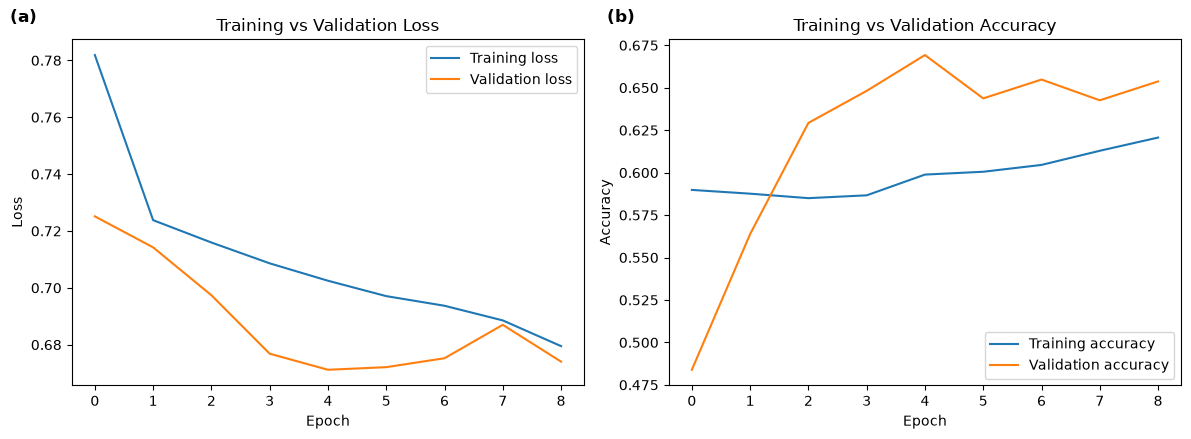

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Validation accuracy:
0.6692563817980022

Validation ROC-AUC:
0.6881728460922913

Validation Macro F1:
0.6500651652590971

Classification report (validation):
              precision    recall  f1-score   support

    Not-good     0.7579    0.7078    0.7320       575
        Good     0.5385    0.6012    0.5681       326

    accuracy                         0.6693       901
   macro avg     0.6482    0.6545    0.6501       901
weighted avg     0.6785    0.6693    0.6727       901

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

FINAL TEST RESULTS
Test accuracy: 0.6149
Test ROC-AUC: 0.6286
Test Macro F1: 0.5890

Classification report:
              precision    recall  f1-score   support

    Not-good     0.7065    0.6783    0.6921       575
        Good     0.4699    0.5031    0.4859       326

    accuracy                         0.6149       901
   macro avg     0.5882    0.5907    0.5890       901
weighted avg     0.6209    0.6149    0.6175       901



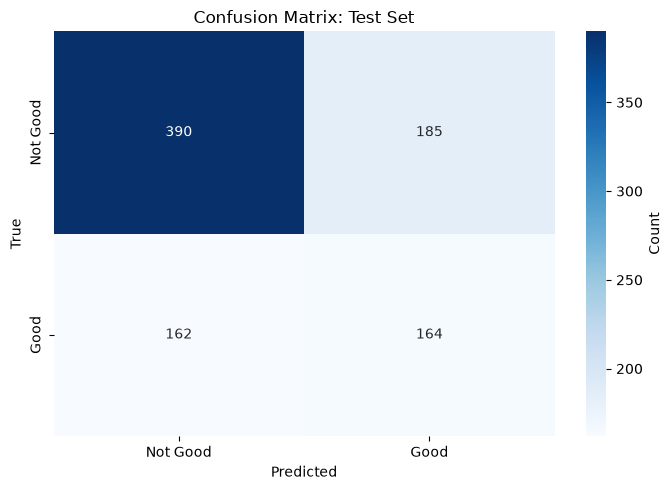

In [21]:
# ============================================================
# METADATA-ONLY MLP
# Binary classification: Good vs Not-good
# 1 = Good
# 0 = Not-good (Moderate + Poor)
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, regularizers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


#Class weights - need this to account for the Not Good class being so much larger than the Good class
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)


#Build the MLP

model = tf.keras.Sequential([

    layers.Input(shape=(X_train.shape[1],)),

    # Hidden layer 1
    layers.Dense(
        512,
        kernel_regularizer=regularizers.l2(5e-5)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.35),

    # Hidden layer 2
    layers.Dense(
        256,
        kernel_regularizer=regularizers.l2(5e-5)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    # Hidden layer 3
    layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(5e-5)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.15),

    # Binary output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])


#The optimiser
opt = optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5
)


#Compile the model with binary cross-entropy loss and metrics for accuracy and AUC
model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


#Callbacks for early stopping and learning rate reduction on plateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)


#Train the model

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=64,

    class_weight=class_weight,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)


#Display the training/vlaidation accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

#Loss
axes[0].plot(
    history.history['loss'],
    label='Training loss'
)
axes[0].plot(
    history.history['val_loss'],
    label='Validation loss'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.0)


#Accuracy
axes[1].plot(
    history.history['accuracy'],
    label='Training accuracy'
)
axes[1].plot(
    history.history['val_accuracy'],
    label='Validation accuracy'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.0)


#Add panel labels
axes[0].text(
    -0.12, 1.05, '(a)',
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight='bold'
)

axes[1].text(
    -0.12, 1.05, '(b)',
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight='bold'
)

#Improve spacing
plt.tight_layout()
plt.savefig("Results/MLP_training_validation_curves.png", dpi=300)
plt.show()

#Display the validation performance

#Sigmoid output = probability of class 1 (Good)
y_val_proba = model.predict(X_val).ravel()

#Apply threshold
y_val_pred = (
    y_val_proba >= 0.5
).astype(int)

print("\nValidation accuracy:")
print(
    accuracy_score(
        y_val,
        y_val_pred
    )
)

print("\nValidation ROC-AUC:")
print(
    roc_auc_score(
        y_val,
        y_val_proba
    )
)

print("\nValidation Macro F1:")
print(
    f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )
)

print("\nClassification report (validation):")

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[
            "Not-good",
            "Good"
        ],
        digits=4
    )
)


#The performance on the unseen test data

test_loss, test_accuracy, test_auc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

y_test_proba = model.predict(
    X_test
).ravel()

y_test_pred = (
    y_test_proba >= 0.5
).astype(int)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(
    f"Test accuracy: {test_accuracy:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

print(
    "Test Macro F1:",
    f"{f1_score(y_test, y_test_pred, average='macro'):.4f}"
)

print("\nClassification report:")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Not-good",
            "Good"
        ],
        digits=4
    )
)


#Make a confusion matrix for the test set performance
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={
        "label": "Count"
    }
)

plt.xticks(
    [0.5, 1.5],
    ["Not Good", "Good"]
)

plt.yticks(
    [0.5, 1.5],
    ["Not Good", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Confusion Matrix: Test Set"
)

plt.tight_layout()
plt.savefig("Results/MLP_test_confusion_matrix.png", dpi=300)
plt.show()

X_train shape: (7202, 64)
X_val shape: (901, 64)
Number of feature names: 64
Background shape: (100, 64)
X_explain shape: (300, 64)


c:\Users\Rebecca Tichford\Documents\Oxford University\Code\team_project\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_28
Received: inputs=['Tensor(shape=(300, 64))']
  warnings.warn(msg)
c:\Users\Rebecca Tichford\Documents\Oxford University\Code\team_project\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_28
Received: inputs=['Tensor(shape=(50, 64))']
  warnings.warn(msg)


Raw SHAP shape: (300, 64, 1)
Final SHAP shape: (300, 64)
X_explain_df shape: (300, 64)


C:\Users\Rebecca Tichford\AppData\Local\Temp\ipykernel_33516\2793855044.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


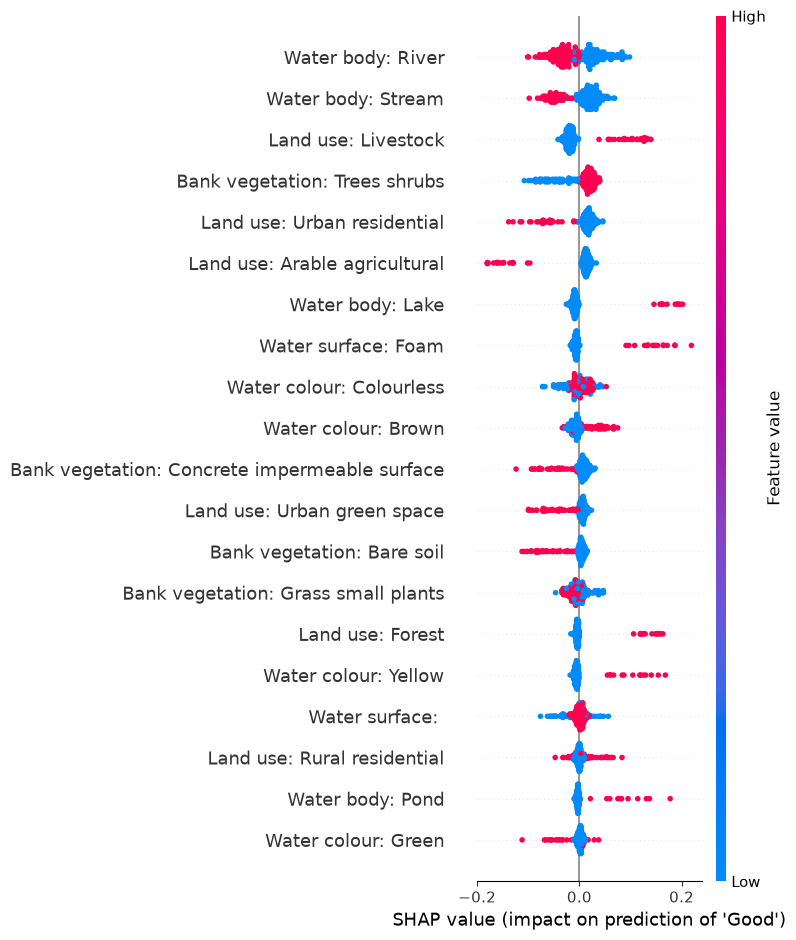

In [25]:
#SHAP values analysis

import shap

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("Number of feature names:", len(feature_names))

assert X_train.shape[1] == len(feature_names), (
    f"Mismatch: X_train has {X_train.shape[1]} features "
    f"but feature_names has {len(feature_names)} names."
)

#Select background and validation samples
np.random.seed(42)

background_indices = np.random.choice(
    X_train.shape[0],
    size=min(100, X_train.shape[0]),
    replace=False
)

background = X_train[background_indices]

#Explain a sample of validation observations
X_explain = X_val

print("Background shape:", background.shape)
print("X_explain shape:", X_explain.shape)

#Create SHAP explainer
explainer = shap.GradientExplainer(
    model,
    background
)

#Calculate SHAP values
shap_values = explainer.shap_values(X_explain)

#Convert to numpy array
shap_values = np.asarray(shap_values)

print("Raw SHAP shape:", shap_values.shape)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

elif shap_values.ndim == 3 and shap_values.shape[0] == 1:
    shap_values = shap_values[0]

print("Final SHAP shape:", shap_values.shape)

#Confirm that SHAP contains all features
assert shap_values.shape[1] == X_explain.shape[1], (
    f"SHAP has {shap_values.shape[1]} features, "
    f"but X_explain has {X_explain.shape[1]}."
)

assert shap_values.shape[1] == len(feature_names), (
    f"SHAP has {shap_values.shape[1]} features, "
    f"but feature_names has {len(feature_names)}."
)

#Feature names - tidy
X_explain_df = pd.DataFrame(
    X_explain,
    columns=feature_names
)

print("X_explain_df shape:", X_explain_df.shape)


#Clean the feature names
def clean_feature_name(name):

    name = str(name)

    name = name.replace("cat__", "")
    name = name.replace("num__", "")

    name = name.replace(
        "Freshwater body type_",
        "Water body: "
    )

    name = name.replace(
        "What is the main land use within 50m?_",
        "Land use: "
    )

    name = name.replace(
        "Is there any of the following on the water surface?_",
        "Water surface: "
    )

    name = name.replace(
        "Estimate the water colour_",
        "Water colour: "
    )

    name = name.replace(
        "bankveg_",
        "Bank vegetation: "
    )

    name = name.replace("_", " ")
    name = name.replace(",", " + ")

    return name


clean_feature_names = [
    clean_feature_name(name)
    for name in feature_names
]

X_explain_df.columns = clean_feature_names

#Make a summary plot

shap.summary_plot(
    shap_values,
    X_explain_df,
    max_display=20,
    show=False
)

#plt.title(
#    "SHAP Feature Importance for Metadata-only MLP",
#    pad=15
#)

plt.xlabel(
    "SHAP value (impact on prediction of 'Good')"
)

plt.tight_layout()
plt.savefig("Results/SHAP_values.png")
plt.show()


In [26]:
#TABLE OF VISUAL CHARACTERISTICS VS WATER QUALITY
#This is something extra I worked on when I was looking at the SHAP values, could explain where the CNN might struggle/succeed?

surface_col = "Is there any of the following on the water surface?"
colour_col = "Estimate the water colour"

results = []

#Helper function - For samples with this visual characteristic, how many are Good and how many are Not Good?
def add_result(feature_name, mask):
    
    mask = np.asarray(mask)

    #Get target values for samples containing this feature
    y_feature = y_bin[mask]

    n = len(y_feature)

    if n > 0:
        good_count = np.sum(y_feature == 1)
        notgood_count = np.sum(y_feature == 0)

        results.append({
            "Visual characteristic": feature_name,
            "n": n,
            "Good (n)": good_count,
            "Good (%)": good_count / n * 100,
            "Not-good (n)": notgood_count,
            "Not-good (%)": notgood_count / n * 100
        })


#Water surface characteristics

surface_features = {
    "Floating algae": "Floating_algae",
    "Foam": "Foam",
    "Oily sheen": "Oily_sheen",
    "Slurry": "Slurry"
}

surface_values = (
    filtered_df[surface_col]
    .astype(str)
)

for display_name, search_term in surface_features.items():

    mask = surface_values.str.contains(
        search_term,
        case=False,
        na=False,
        regex=False
    ).values

    add_result(display_name, mask)


#Water colour characteristics
#See which categories actually exist
print("Water colour categories:")
print(filtered_df[colour_col].value_counts())


colour_features = [
    "Brown",
    "Green",
    "Colourless"
]

colour_values = (
    filtered_df[colour_col]
    .astype(str)
    .str.strip()
)

for colour in colour_features:

    mask = colour_values.eq(colour).values

    add_result(
        f"{colour} water",
        mask
    )


#Create a summary table
visual_summary = pd.DataFrame(results)

#Round percentages
visual_summary["Good (%)"] = (
    visual_summary["Good (%)"].round(1)
)

visual_summary["Not-good (%)"] = (
    visual_summary["Not-good (%)"].round(1)
)

#Sort by sample size
visual_summary = visual_summary.sort_values(
    "n",
    ascending=False
).reset_index(drop=True)


print("\nVisual characteristics and water-quality class:\n")

print(
    visual_summary.to_string(index=False)
)

Water colour categories:
Estimate the water colour
Colourless     5381
Brown          2241
Green           646
Yellow          321
Grey            202
Other           155
White_milky      58
Name: count, dtype: int64

Visual characteristics and water-quality class:

Visual characteristic    n  Good (n)  Good (%)  Not-good (n)  Not-good (%)
     Colourless water 5381      1965      36.5          3416          63.5
          Brown water 2241       869      38.8          1372          61.2
                 Foam  727       359      49.4           368          50.6
          Green water  646       152      23.5           494          76.5
       Floating algae  580       169      29.1           411          70.9
               Slurry  309        85      27.5           224          72.5
           Oily sheen  190        52      27.4           138          72.6


In [27]:
#MODEL COMPARISON:
#MLP vs Logistic Regression vs Random Forest
#Credits - ChatGPT coded the logistic regression and random forest parts. 

#MLP
#Predicted probabilities from the already-trained MLP
mlp_proba = model.predict(X_val).ravel()

#Use the 0.5 threshold
mlp_pred = (mlp_proba >= 0.5).astype(int)

mlp_results = {
    "Model": "MLP",
    "Accuracy": accuracy_score(y_val, mlp_pred),
    "Precision (Good)": precision_score(y_val, mlp_pred),
    "Recall (Good)": recall_score(y_val, mlp_pred),
    "Macro F1": f1_score(y_val, mlp_pred, average="macro"),
    "ROC-AUC": roc_auc_score(y_val, mlp_proba)
}

# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr.fit(X_train, y_train)

# Predicted probability of Good (class 1)
lr_proba = lr.predict_proba(X_val)[:, 1]

# Apply 0.5 threshold
lr_pred = (lr_proba >= 0.5).astype(int)

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, lr_pred),
    "Precision (Good)": precision_score(y_val, lr_pred),
    "Recall (Good)": recall_score(y_val, lr_pred),
    "Macro F1": f1_score(y_val, lr_pred, average="macro"),
    "ROC-AUC": roc_auc_score(y_val, lr_proba)
}


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicted probability of Good (class 1)
rf_proba = rf.predict_proba(X_val)[:, 1]

# Apply 0.5 threshold
rf_pred = (rf_proba >= 0.5).astype(int)

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_val, rf_pred),
    "Precision (Good)": precision_score(y_val, rf_pred),
    "Recall (Good)": recall_score(y_val, rf_pred),
    "Macro F1": f1_score(y_val, rf_pred, average="macro"),
    "ROC-AUC": roc_auc_score(y_val, rf_proba)
}


#Make a comparison table to evaluate the models
results_df = pd.DataFrame([mlp_results, lr_results, rf_results])

#Round results for easier reading
results_df = results_df.round(4)

print("\nValidation-set model comparison:\n")
print(results_df.to_string(index=False))


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Validation-set model comparison:

              Model  Accuracy  Precision (Good)  Recall (Good)  Macro F1  ROC-AUC
                MLP    0.6693            0.5385         0.6012    0.6501   0.6882
Logistic Regression    0.6337            0.4949         0.5920    0.6176   0.6806
      Random Forest    0.6393            0.5013         0.5920    0.6225   0.6512
